# 📊 Project 01 — Customer Retention & Revenue Analytics
## Step 3: Exploratory Data Analysis (EDA) & Cohort Analysis

**Goal:** Visualise churn patterns, build a retention heatmap, and surface key business insights.

### What is EDA?
> EDA = Exploratory Data Analysis. Before building any model, we **make charts and tables** to understand what the data is telling us. We look for patterns: *Which plan has the most churn? Which customers are highest risk?*

### What is Cohort Analysis?
> Group customers by **when they signed up** (e.g., January 2022) and track how many are still active after 1 month, 2 months, 3 months, etc. This reveals WHEN customers tend to leave.

---
### Charts we will create:
1. 📊 Churn rate by Plan, Channel, and Risk Segment
2. 🟩 Retention Heatmap (Cohort × Tenure Month)
3. 📊 RFM Score Distributions
4. 💰 MRR at Risk by Segment
5. 📊 Feature Adoption: Churned vs Retained

## 📦 Cell 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

# Make charts appear directly in the notebook
%matplotlib inline

# Set a clean visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120   # sharper charts

# Risk segment colour coding
RISK_COLORS = {
    "Low Risk":    "#2ECC71",   # green
    "Medium Risk": "#F39C12",   # orange
    "High Risk":   "#E74C3C",   # red
}

# Where to save chart images
CHART_DIR = "./outputs/charts"
os.makedirs(CHART_DIR, exist_ok=True)

print("✅ Libraries loaded!")

✅ Libraries loaded!


## 📥 Cell 2: Load the Master Analytics Table

In [5]:
MAT_PATH = "./data/mat/master_analytics_table.csv"

mat = pd.read_csv(MAT_PATH)

# Parse date columns
for col in ["signup_date", "start_date", "cancel_date", "last_activity_date", "last_payment_date"]:
    if col in mat.columns:
        mat[col] = pd.to_datetime(mat[col], errors="coerce")

print(f"✅ MAT loaded: {mat.shape[0]:,} customers × {mat.shape[1]} columns")
print(f"   Overall churn rate: {mat['churned'].mean()*100:.1f}%")
mat.head(2)

✅ MAT loaded: 12,000 customers × 64 columns
   Overall churn rate: 23.8%


,subscription_id,user_id,plan_id_sub,plan_name_sub,billing_cycle,monthly_price_usd,mrr_usd,status,start_date,cancel_date,...,feature_adoption_score,login_frequency_monthly,failed_payment_rate,events_per_day,cohort_month,rfm_recency,rfm_frequency,rfm_monetary,rfm_score,risk_segment
0,SUB-000001,USR-00001,PLN-003,Professional,Monthly,79.99,79.99,Active,2021-02-21,NaT,...,8,0.383251,0.042553,0.141945,2021-02,3,3,4,10,Medium Risk
1,SUB-000002,USR-00002,PLN-001,Basic,Annual,9.99,8.33,Active,2021-03-07,NaT,...,8,0.473118,0.000000,0.143369,2021-03,4,4,1,9,Medium Risk


## 📊 Cell 3: Quick Summary Stats
Get the key numbers before drawing charts.

In [6]:
# Identify plan name column (may have a suffix from the join)
plan_col = "plan_name_x" if "plan_name_x" in mat.columns else "plan_name"

print("="*50)
print("  KEY BUSINESS METRICS")
print("="*50)
print(f"  Total Customers       : {len(mat):,}")
print(f"  Overall Churn Rate    : {mat['churned'].mean()*100:.1f}%")

active_mask = mat["status"] == "Active" if "status" in mat.columns else mat["churned"] == 0
print(f"  Total Active MRR      : ${mat.loc[active_mask, 'mrr_usd'].sum():,.0f}")
print(f"  High-Risk Customers   : {(mat['risk_segment']=='High Risk').sum():,}")
print(f"  MRR at Risk (High)    : ${mat.loc[mat['risk_segment']=='High Risk','mrr_usd'].sum():,.0f}")

# Churn by plan
churn_by_plan = mat.groupby("plan_name_sub")["churned"].mean().sort_values(ascending=False)
print(f"\n  Highest-churn Plan    : {churn_by_plan.idxmax()} ({churn_by_plan.max()*100:.1f}%)")
print(f"  Lowest-churn Plan     : {churn_by_plan.idxmin()} ({churn_by_plan.min()*100:.1f}%)")

# Churn by channel
churn_by_channel = mat.groupby("acquisition_channel")["churned"].mean().sort_values(ascending=False)
print(f"  Highest-churn Channel : {churn_by_channel.idxmax()} ({churn_by_channel.max()*100:.1f}%)")

  KEY BUSINESS METRICS
  Total Customers       : 12,000
  Overall Churn Rate    : 23.8%
  Total Active MRR      : $383,429
  High-Risk Customers   : 3,616
  MRR at Risk (High)    : $87,285

  Highest-churn Plan    : Basic (37.7%)
  Lowest-churn Plan     : Enterprise (6.9%)
  Highest-churn Channel : Paid Search (27.5%)


## 📊 Cell 4: Chart 1 — Churn Overview (Plan, Channel, Risk Segment)

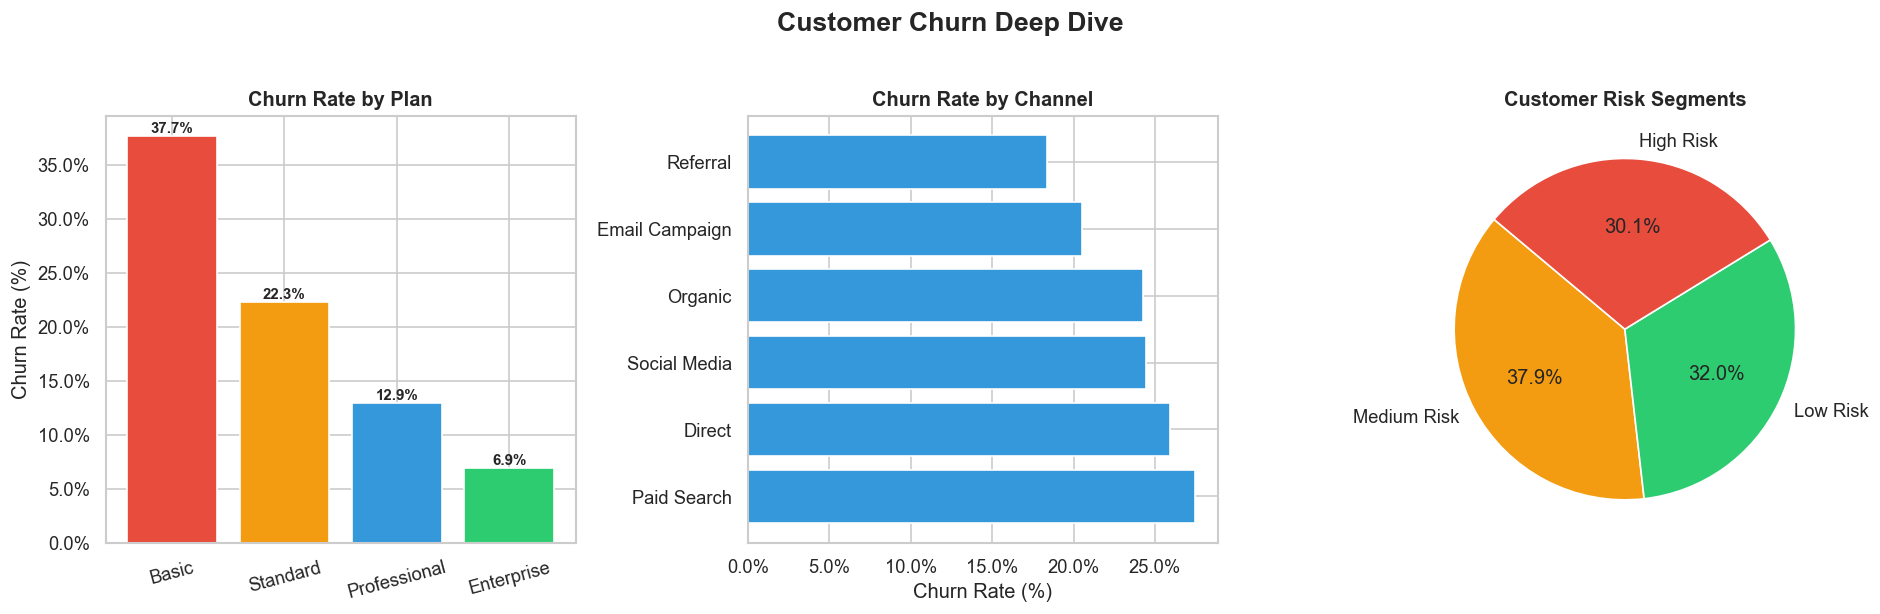

  ✅ Chart 1 saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Customer Churn Deep Dive", fontsize=16, fontweight="bold", y=1.02)

# ── Chart A: Churn Rate by Plan ────────────────────────────
ax = axes[0]
plan_colors = ["#E74C3C", "#F39C12", "#3498DB", "#2ECC71"]
bars = ax.bar(churn_by_plan.index, churn_by_plan.values * 100, color=plan_colors[:len(churn_by_plan)])
ax.set_title("Churn Rate by Plan", fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())   # show % on y-axis
ax.tick_params(axis="x", rotation=15)

# Add the % number on top of each bar
for bar, val in zip(bars, churn_by_plan.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val*100:.1f}%", ha="center", fontsize=9, fontweight="bold")

# ── Chart B: Churn Rate by Acquisition Channel ─────────────
ax = axes[1]
ax.barh(churn_by_channel.index, churn_by_channel.values * 100, color="#3498DB", edgecolor="white")
ax.set_title("Churn Rate by Channel", fontweight="bold")
ax.set_xlabel("Churn Rate (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# ── Chart C: Risk Segment Pie Chart ────────────────────────
ax = axes[2]
seg_counts = mat["risk_segment"].value_counts()
colors = [RISK_COLORS.get(s, "#95A5A6") for s in seg_counts.index]
ax.pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
       colors=colors, startangle=140)
ax.set_title("Customer Risk Segments", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_churn_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Chart 1 saved!")

## 🟩 Cell 5: Chart 2 — Cohort Retention Heatmap

### How to read this heatmap:
- **Rows** = the month customers signed up (cohort)
- **Columns** = how many months after signup (tenure)
- **Cell value** = % of that cohort still active at that tenure month
- 🟢 Green = high retention | 🔴 Red = high dropout

> **Key insight to look for:** Which tenure months have the most red? That's when customers leave.

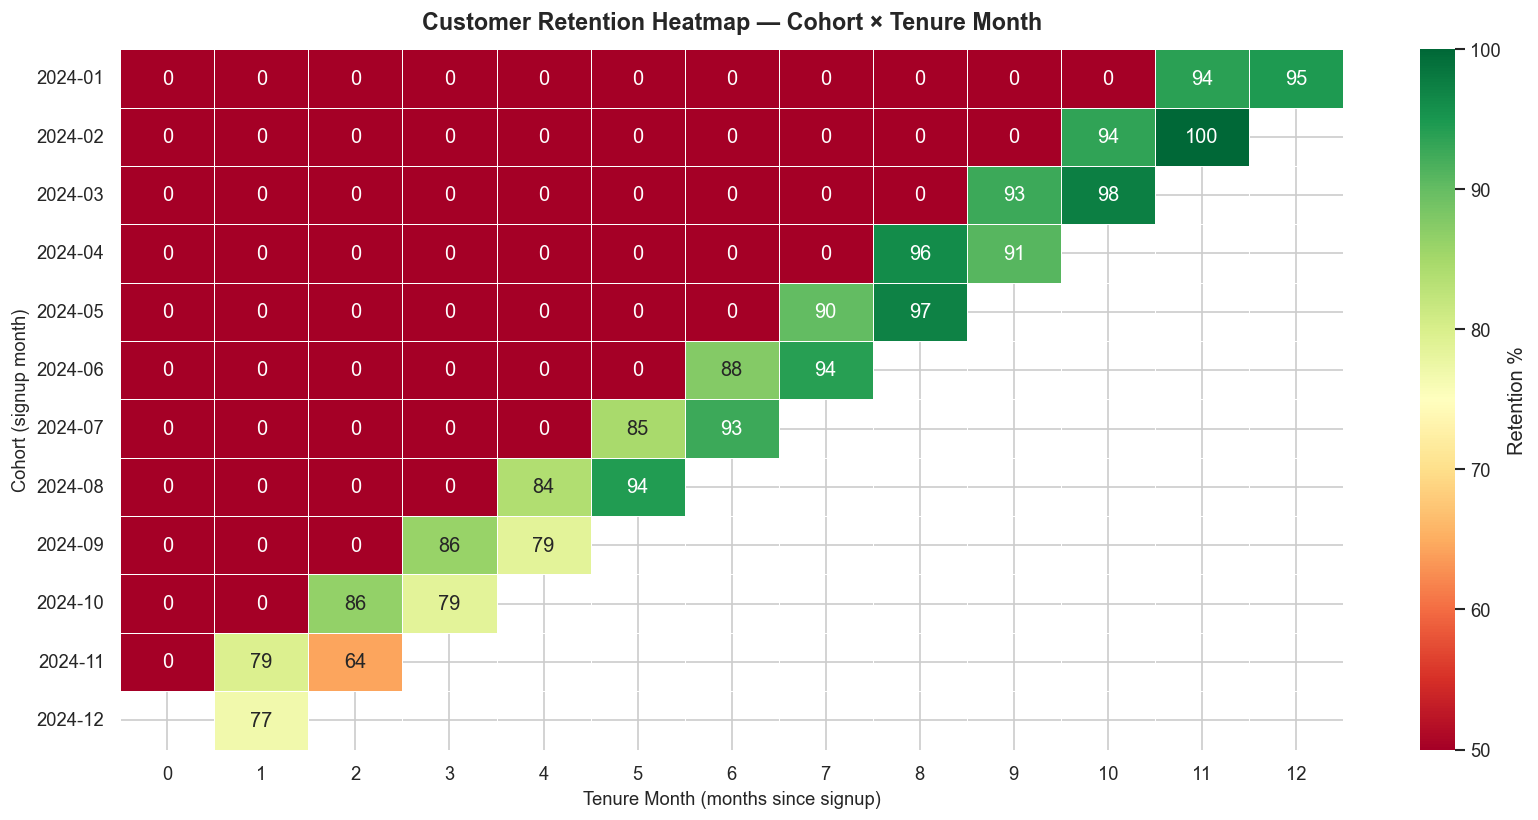

  ✅ Chart 2 saved!

  💡 Look for the reddest months — those are when most customers drop off!


In [8]:
# Step 1: Create a 'tenure_month' column
# (how many full months has the customer been subscribed?)
mat["tenure_month"] = (mat["tenure_days"] / 30).astype(int).clip(upper=24)

# Step 2: For each cohort × tenure combination, calculate retention %
# retention % = 1 - churn rate (at that snapshot)
cohort_data = mat.groupby(["cohort_month", "tenure_month"])["churned"].apply(
    lambda x: (1 - x.mean()) * 100   # retention = 100% minus churn rate
).reset_index()
cohort_data.columns = ["cohort_month", "tenure_month", "retention_pct"]

# Step 3: Pivot into a heatmap format (rows = cohorts, columns = months)
pivot = cohort_data.pivot(index="cohort_month", columns="tenure_month", values="retention_pct")

# Show last 12 cohorts, months 0-12
pivot = pivot.iloc[-12:, :13]

# Step 4: Draw the heatmap
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    pivot,
    annot=True,          # show numbers in each cell
    fmt=".0f",           # format as integer
    cmap="RdYlGn",       # Red-Yellow-Green colour scale
    vmin=50, vmax=100,   # scale: 50% (red) to 100% (green)
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Retention %"}
)

ax.set_title("Customer Retention Heatmap — Cohort × Tenure Month",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Tenure Month (months since signup)", fontsize=11)
ax.set_ylabel("Cohort (signup month)", fontsize=11)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_cohort_retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Chart 2 saved!")
print("\n  💡 Look for the reddest months — those are when most customers drop off!")

## 📊 Cell 6: Chart 3 — RFM Score Distributions
See how customers are distributed across Recency, Frequency, and Monetary scores.

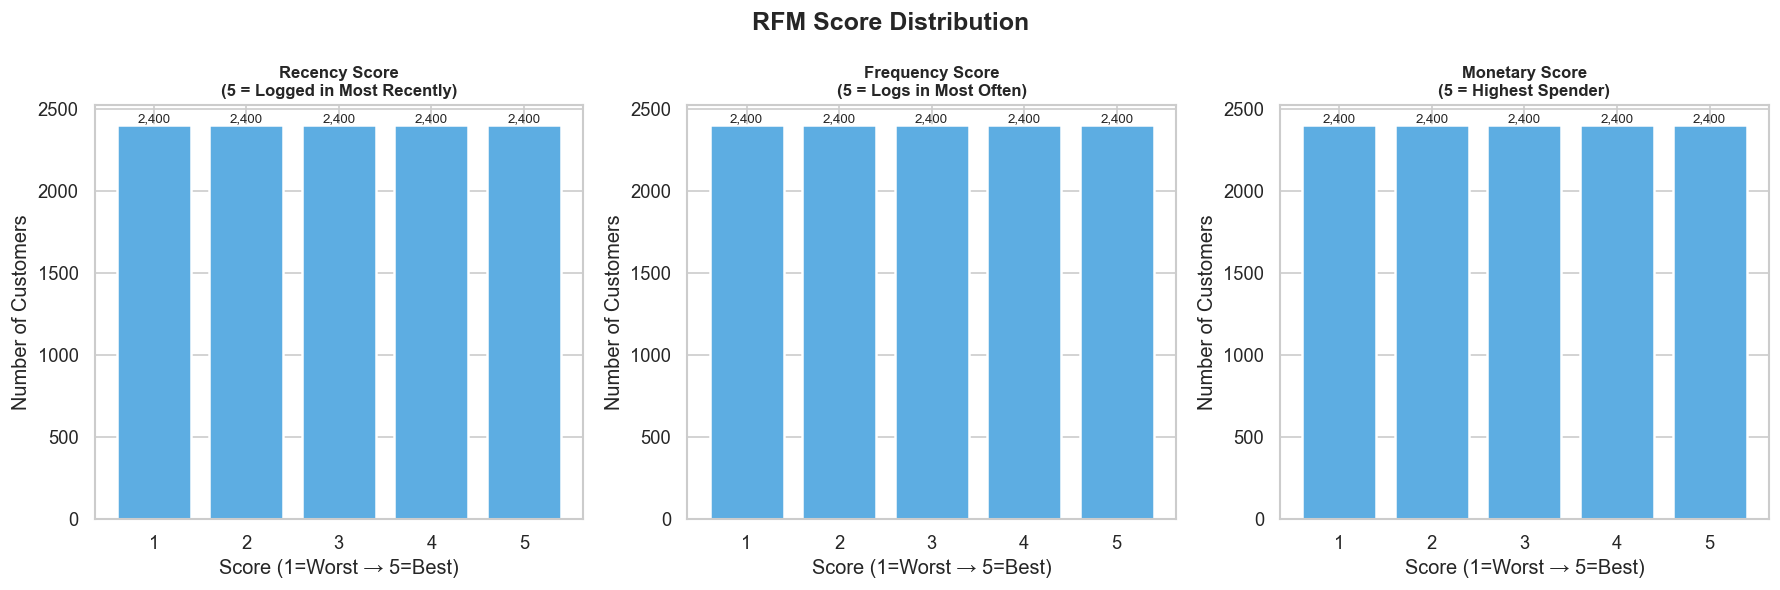

  ✅ Chart 3 saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("RFM Score Distribution", fontsize=15, fontweight="bold")

rfm_info = [
    ("rfm_recency",   "Recency Score\n(5 = Logged in Most Recently)"),
    ("rfm_frequency", "Frequency Score\n(5 = Logs in Most Often)"),
    ("rfm_monetary",  "Monetary Score\n(5 = Highest Spender)"),
]

for ax, (col, title) in zip(axes, rfm_info):
    counts = mat[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#5DADE2", edgecolor="white", linewidth=1.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Score (1=Worst → 5=Best)")
    ax.set_ylabel("Number of Customers")
    ax.set_xticks([1, 2, 3, 4, 5])

    # Label each bar with the count
    for x, y in zip(counts.index, counts.values):
        ax.text(x, y + 20, f"{y:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_rfm_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Chart 3 saved!")

## 💰 Cell 7: Chart 4 — MRR at Risk by Segment
How much monthly revenue is at risk from each risk segment?

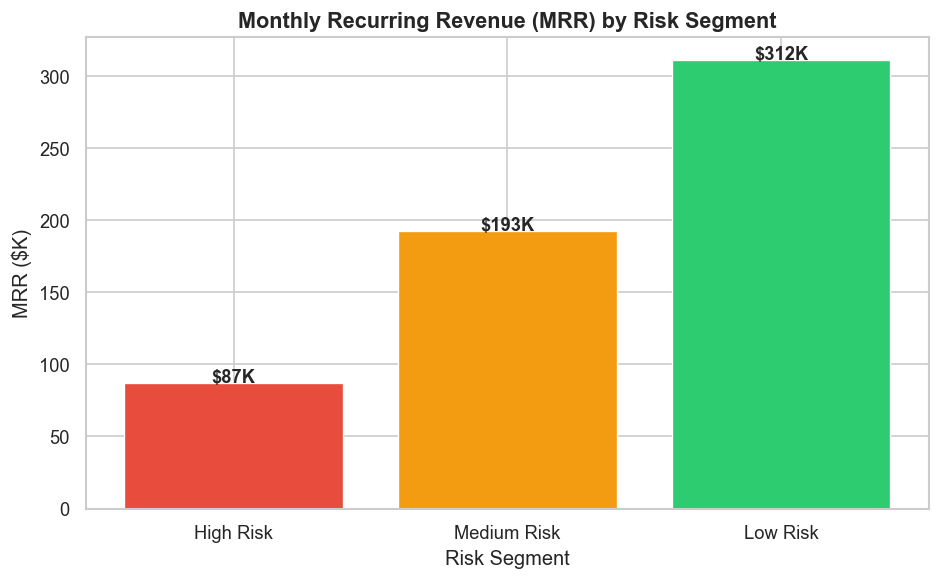

  ✅ Chart 4 saved!
  💡 High-Risk MRR at risk: $87K


In [10]:
# Calculate total MRR per risk segment
mrr_by_segment = mat.groupby("risk_segment")["mrr_usd"].sum().reindex(
    ["High Risk", "Medium Risk", "Low Risk"]
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = [RISK_COLORS[s] for s in mrr_by_segment.index]
bars = ax.bar(mrr_by_segment.index, mrr_by_segment.values / 1000,
              color=colors, edgecolor="white", linewidth=0.8)

# Add dollar amount labels on top of each bar
for bar, val in zip(bars, mrr_by_segment.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${val/1000:,.0f}K", ha="center", fontsize=11, fontweight="bold")

ax.set_title("Monthly Recurring Revenue (MRR) by Risk Segment",
             fontsize=13, fontweight="bold")
ax.set_ylabel("MRR ($K)")
ax.set_xlabel("Risk Segment")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_mrr_at_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print("  ✅ Chart 4 saved!")
print(f"  💡 High-Risk MRR at risk: ${mrr_by_segment['High Risk']/1000:,.0f}K")

## 📊 Cell 8: Chart 5 — Feature Adoption vs Churn
Do customers who use more features churn less? This chart answers that question.

C:\Users\91930\AppData\Local\Temp\ipykernel_17440\2219742929.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\91930\AppData\Local\Temp\ipykernel_17440\2219742929.py:22: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\91930\AppData\Local\Temp\ipykernel_17440\2219742929.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f"{CHART_DIR}/05_adoption_vs_churn.png", dpi=150, bbox_inches="tight")
C:\Users\91930\AppData\Local\Temp\ipykernel_17440\2219742929.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig(f"{CHART_DIR}/05_adoption_vs_churn.png", dpi=150, bbox_inches="tight")
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\a

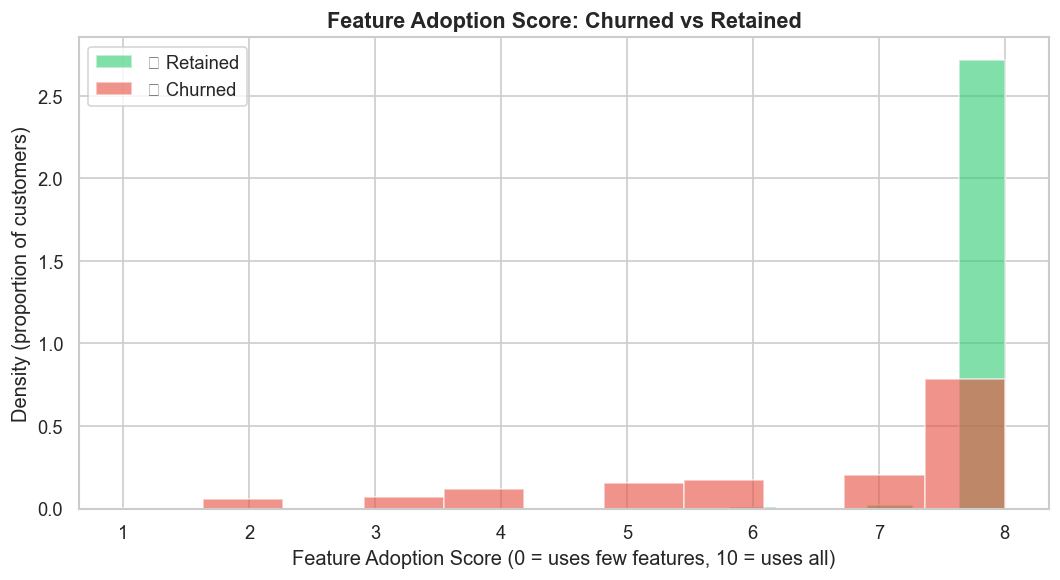

  ✅ Chart 5 saved!
  📊 Avg adoption score (Retained): 7.98
  📊 Avg adoption score (Churned) : 6.58
  💡 Retained customers use more features!


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

# Draw one histogram for churned customers and one for retained
for churn_label, group in mat.groupby("churned"):
    label = "❌ Churned" if churn_label == 1 else "✅ Retained"
    color = "#E74C3C"    if churn_label == 1 else "#2ECC71"
    ax.hist(
        group["feature_adoption_score"].dropna(),
        bins=11,
        alpha=0.6,          # semi-transparent so both histograms are visible
        label=label,
        color=color,
        density=True        # normalise so both can be compared fairly
    )

ax.set_title("Feature Adoption Score: Churned vs Retained",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Adoption Score (0 = uses few features, 10 = uses all)")
ax.set_ylabel("Density (proportion of customers)")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_adoption_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the average score for each group
avg_scores = mat.groupby("churned")["feature_adoption_score"].mean()
print(f"  ✅ Chart 5 saved!")
print(f"  📊 Avg adoption score (Retained): {avg_scores[0]:.2f}")
print(f"  📊 Avg adoption score (Churned) : {avg_scores[1]:.2f}")
print(f"  💡 {'Retained' if avg_scores[0] > avg_scores[1] else 'Churned'} customers use more features!")

## 📋 Cell 9: Key Findings Summary

In [12]:
print("="*55)
print("  KEY FINDINGS FROM EDA")
print("="*55)
print(f"  Overall churn rate        : {mat['churned'].mean()*100:.1f}%")

active_mrr = mat.loc[mat["churned"]==0, "mrr_usd"].sum()
print(f"  Total Active MRR          : ${active_mrr:,.0f}")
print(f"  High-risk customers       : {(mat['risk_segment']=='High Risk').sum():,}")
high_risk_mrr = mat.loc[mat['risk_segment']=='High Risk','mrr_usd'].sum()
print(f"  MRR at risk (High Risk)   : ${high_risk_mrr:,.0f}")
print(f"  Highest-churn plan        : {churn_by_plan.idxmax()} ({churn_by_plan.max()*100:.1f}%)")
print(f"  Lowest-churn plan         : {churn_by_plan.idxmin()} ({churn_by_plan.min()*100:.1f}%)")
print(f"  Highest-churn channel     : {churn_by_channel.idxmax()} ({churn_by_channel.max()*100:.1f}%)")
print(f"\n  📂 Charts saved to: {CHART_DIR}/")
print("\n  👉 Next Step: Run step04_churn_model.ipynb")

  KEY FINDINGS FROM EDA
  Overall churn rate        : 23.8%
  Total Active MRR          : $509,666
  High-risk customers       : 3,616
  MRR at risk (High Risk)   : $87,285
  Highest-churn plan        : Basic (37.7%)
  Lowest-churn plan         : Enterprise (6.9%)
  Highest-churn channel     : Paid Search (27.5%)

  📂 Charts saved to: ./outputs/charts/

  👉 Next Step: Run step04_churn_model.ipynb
